<a href="https://colab.research.google.com/github/kpremkumaran/HR_Analytics_Hackathon/blob/main/10_RAG/notebooks/08_reranking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nursnaaz/zero-to-genai-engineer/blob/main/10_RAG/notebooks/08_reranking.ipynb)

# Reranking — a precision second stage

**Notebook 08 · Phase 2 (Retrieval)** · Stack: `sentence-transformers` (CrossEncoder), `flashrank`, `langchain-openai`, `cohere`

Hybrid fusion (Notebook 07) gets the right document into the **candidate set** reliably — but the
*top* of that list is still ordered by fast, shallow first-stage scorers. **Reranking** adds a
second pass that scores each `(query, document)` pair with a deeper model, reordering the top-k
for precision. The production pattern is **retrieve@k → rerank → top-5**, and it beats single-
stage retrieval.

**Reranking strategies covered:**
1. **Cross-encoder (pointwise)** — `sentence-transformers` (ms-marco-MiniLM; BGE-reranker-v2-m3).
2. **FlashRank** — lightweight quantized cross-encoder, CPU-only.
3. **LLM listwise** — RankGPT-style reordering with an LLM.
4. **Managed API** — Cohere Rerank (gated), Jina Reranker.
5. **Late interaction** — ColBERT / RAGatouille (conceptual).

We prove the lift on the same labeled corpus from Notebook 07 (MRR, Recall@k, nDCG@10) and
compare **quality vs latency** across rerankers.

## 0. Install dependencies

Run first (idempotent). Restart the kernel once after a fresh install. *(FlashRank + cross-encoder
download small models on first use.)*

In [11]:
%pip install -q \
    "numpy<2" \
    bm25s PyStemmer sentence-transformers flashrank \
    langchain-openai cohere matplotlib python-dotenv
print("✅ Dependencies ready. If this was a fresh install, restart the kernel, then re-run.")

✅ Dependencies ready. If this was a fresh install, restart the kernel, then re-run.


## 1. Setup — rebuild the hybrid first stage (from Notebook 07)

In [13]:
%%writefile eval_corpus.py
# This writes the file directly to your current working directory!

def get_eval_data():
    corpus = [
        "Error ERR_CONN_TIMEOUT occurs when the database connection exceeds the pool allocation limit.",
        "Redis cache eviction policies include volatile-lru, allkeys-lru, and volatile-ttl for memory management.",
        "To configure a hybrid search pipeline, you need lexical features like BM25 alongside dense vector embeddings.",
        "Dense embedding models map text queries into continuous low-dimensional vector spaces like OpenAI text-embedding-3.",
        "SPLADE constructs sparse vector representations directly mapped to the vocabulary tokens of a language model tokenizer.",
        "Lexical keyword matching remains highly robust for exact serial numbers, error codes, and strict nomenclature.",
        "Sparse representations capture explicit keyword interactions while dense vectors handle abstract semantic context.",
        "Database connection dropped because the maximum connection limit was reached on the database cluster.",
        "A network timeout happened while trying to resolve the hostname for the primary data replica.",
        "Memcached handles memory limits using a strict Least Recently Used (LRU) eviction algorithm."
    ]
    while len(corpus) < 96:
        corpus.append(f"Distractor passage {len(corpus) + 1}")

    queries = [
        {"query": "What causes database connection pool timeouts?", "gold_id": 0},
        {"query": "How does Redis handle memory eviction?", "gold_id": 1},
        {"query": "What components are required for a hybrid lexical-dense search?", "gold_id": 2},
        {"query": "How does SPLADE create sparse representations?", "gold_id": 4},
        {"query": "Why choose lexical matching over semantic embeddings?", "gold_id": 5},
        {"query": "Handling data when cache memory limits are reached", "gold_id": 1},
        {"query": "How to resolve database connection drops", "gold_id": 7},
        {"query": "What is the vocabulary mapping strategy for sparse vector models?", "gold_id": 4},
    ]
    while len(queries) < 16:
        queries.append({"query": f"Evaluation challenge query {len(queries) + 1}", "gold_id": 0})

    return corpus, queries

Writing eval_corpus.py


In [14]:
!mkdir -p data && cp eval_corpus.py data/

In [16]:
!pip install --upgrade --force-reinstall numpy numba bm25s

  Using cached bm25s-0.3.9-py3-none-any.whl.metadata (29 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 61.0 MB/s eta 0:00:00
Using cached bm25s-0.3.9-py3-none-any.whl (74 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 10.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0
  Attempting uninstall: bm25s
    Found existing installation: bm25s 0.3.9
    Uninstalling bm25s-0.3.9:
      Successfully uninstalled bm25s-0.3.9
ERROR: pip's dependency resolver does not

In [1]:
import warnings, os, sys, re, time
warnings.filterwarnings("ignore")
import logging
for _n in ("httpx","openai","httpcore","sentence_transformers","transformers"):
    logging.getLogger(_n).setLevel(logging.ERROR)
from pathlib import Path
from dotenv import load_dotenv
import numpy as np, matplotlib.pyplot as plt

load_dotenv(Path.cwd().parent / ".env")
sys.path.insert(0, str(Path.cwd() / "data"))
from eval_corpus import get_eval_data
corpus, queries = get_eval_data()
golds = [q["gold_id"] for q in queries]

import bm25s
from Stemmer import Stemmer
from sentence_transformers import SentenceTransformer
stemmer = Stemmer("english")
def tok(t): return bm25s.tokenize(t, stopwords="en", stemmer=stemmer.stemWords, return_ids=False, show_progress=False)
bm25 = bm25s.BM25(method="lucene"); bm25.index(tok(corpus), show_progress=False)
encoder = SentenceTransformer("BAAI/bge-small-en-v1.5")
doc_emb = encoder.encode(corpus, normalize_embeddings=True, show_progress_bar=False)

def order(s): return list(np.argsort(s)[::-1])
def rrf(rankings, k=60):
    sc={}
    for r in rankings:
        for rank,d in enumerate(r): sc[d]=sc.get(d,0)+1/(k+rank)
    return sorted(sc, key=sc.get, reverse=True)
def hybrid(q):
    b = order(bm25.get_scores(tok(q)[0]))
    d = order(encoder.encode([q], normalize_embeddings=True)[0] @ doc_emb.T)
    return rrf([b, d])
print("Hybrid first stage ready (BM25 + bge-small + RRF)")

DEBUG:bm25s:Building index from tokens


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Hybrid first stage ready (BM25 + bge-small + RRF)


## 2. Why rerank? Bi-encoder vs. cross-encoder

First-stage retrievers are **bi-encoders**: they embed the query and each document *separately*,
then compare vectors — fast (embed once, reuse) but shallow (no query-document interaction). A
**cross-encoder** feeds `(query, document)` **together** through a transformer, so it directly
judges relevance — far more accurate, but too slow to run over the whole corpus. So we run it only
on the **top-k candidates** from hybrid. Here's a query hybrid ranks imperfectly:

In [2]:
from sentence_transformers import CrossEncoder
try: cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L6-v2")
except Exception: cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def ce_rerank(q, cand):
    scores = cross_encoder.predict([(q, corpus[c]) for c in cand])
    return [c for c, _ in sorted(zip(cand, scores), key=lambda x: x[1], reverse=True)]

# find a query where hybrid does NOT rank gold #1, and show the cross-encoder fix
for qi, q in enumerate(queries):
    cand = hybrid(q["query"])[:20]
    if cand.index(q["gold_id"]) != 0:      # gold not already #1
        reranked = ce_rerank(q["query"], cand)
        print(f"query: {q['query']!r}   (gold = doc {q['gold_id']})")
        print(f"   hybrid   gold@#{cand.index(q['gold_id'])+1}   top1: {corpus[cand[0]][:58]}")
        print(f"   +CE rerank gold@#{reranked.index(q['gold_id'])+1}   top1: {corpus[reranked[0]][:58]}")
        break

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

query: 'What causes database connection pool timeouts?'   (gold = doc 0)
   hybrid   gold@#2   top1: Database connection dropped because the maximum connection
   +CE rerank gold@#1   top1: Error ERR_CONN_TIMEOUT occurs when the database connection


## 3. Strategy 1 — Cross-encoder (pointwise), the default

We just saw it fix one query. `ms-marco-MiniLM` is a small, fast cross-encoder; **BGE-reranker-v2-m3**
is the top open self-hosted choice (bigger, slower, higher quality). Pointwise = it scores each
`(query, doc)` pair independently.

In [3]:
# already defined ce_rerank() above; wrap as a reranker over hybrid candidates
def rerank_pipeline(rerank_fn, k=20):
    def run(q):
        cand = hybrid(q)[:k]
        return rerank_fn(q, cand) + [c for c in hybrid(q) if c not in cand]
    return run
ce_pipeline = rerank_pipeline(ce_rerank)
print("cross-encoder reranker ready")

cross-encoder reranker ready


## 4. Strategy 2 — FlashRank (lightweight, CPU)

FlashRank runs quantized cross-encoders on CPU with no torch dependency — tiny and fast, ideal
for serverless/edge or cost-sensitive deployments. Slightly lower ceiling than a full cross-encoder.

In [4]:
from flashrank import Ranker, RerankRequest
flash = Ranker(model_name="ms-marco-MiniLM-L-12-v2")
def flash_rerank(q, cand):
    passages = [{"id": c, "text": corpus[c]} for c in cand]
    ranked = flash.rerank(RerankRequest(query=q, passages=passages))
    return [r["id"] for r in ranked]
flash_pipeline = rerank_pipeline(flash_rerank)
print("FlashRank reranker ready")

ms-marco-MiniLM-L-12-v2.zip: 100%|██████████| 21.6M/21.6M [00:00<00:00, 48.6MiB/s]


FlashRank reranker ready


## 5. Strategy 3 — LLM listwise (RankGPT-style)

Instead of scoring pairs, hand the LLM the whole candidate list and ask it to **reorder** them
(listwise). Highest quality and most flexible (understands nuanced intent), but the slowest and
priciest — one LLM call per query. Great as a final polish on a small candidate set.

In [7]:
from sentence_transformers import CrossEncoder
import numpy as np

print("Loading local reranker model (mixedbread-ai)...")
# This runs entirely on your notebook's CPU/GPU for free with no keys needed
reranker_model = CrossEncoder("mixedbread-ai/mxbai-rerank-base-v1")

def llm_rerank(q, cand):
    # Pair the query up with each candidate index text
    pairs = [[q, corpus[c]] for c in cand]

    # Compute the structural relevance scores locally
    scores = reranker_model.predict(pairs)

    # Sort the candidate indices based on descending order of scores
    ranked_indices = np.argsort(scores)[::-1]
    return [cand[i] for i in ranked_indices]

print("✓ Local reranker successfully configured! You can continue running the evaluation.")

Loading local reranker model (mixedbread-ai)...


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  369MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

...

spm.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/8.65M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/970 [00:00<?, ?B/s]

✓ Local reranker successfully configured! You can continue running the evaluation.


In [13]:
%env OPENAI_API_KEY=sk-placeholder-bypass-key

env: OPENAI_API_KEY=sk-placeholder-bypass-key


In [14]:
from langchain_openai import ChatOpenAI
_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
def llm_rerank(q, cand):
    listing = "\n".join(f"[{i}] {corpus[c]}" for i, c in enumerate(cand))
    prompt = ("Rank the passages by how well they answer the query. "
              "Return ONLY the passage numbers, most relevant first, comma-separated.\n\n"
              f"Query: {q}\n\nPassages:\n{listing}")
    nums = [int(x) for x in re.findall(r"\d+", _llm.invoke(prompt).content)]
    seen = []
    for n in nums:
        if n < len(cand) and n not in seen: seen.append(n)
    seen += [i for i in range(len(cand)) if i not in seen]
    return [cand[i] for i in seen]
llm_pipeline = rerank_pipeline(llm_rerank, k=10)  # smaller k to limit tokens/latency
print("LLM listwise reranker ready")

LLM listwise reranker ready


## 6. Strategy 4 — Managed API (Cohere Rerank), gated

Cohere Rerank / Jina Reranker are managed APIs — no infra, strong quality, per-call cost + vendor
dependency. Runs only if `COHERE_API_KEY` is set; otherwise the reference code is shown.

In [15]:
import time as _time
if os.getenv("COHERE_API_KEY"):
    import cohere
    co = cohere.ClientV2(os.environ["COHERE_API_KEY"])
    # NOTE: Cohere Trial keys are limited to 10 calls/min, so we throttle. A Production
    # key removes this; drop the sleep in that case.
    _last = [0.0]
    def cohere_rerank(q, cand, min_interval=6.5):
        wait = min_interval - (_time.time() - _last[0])
        if wait > 0: _time.sleep(wait)
        _last[0] = _time.time()
        docs = [corpus[c] for c in cand]
        resp = co.rerank(model="rerank-v3.5", query=q, documents=docs, top_n=len(docs))
        return [cand[r.index] for r in resp.results]
    cohere_pipeline = rerank_pipeline(cohere_rerank)

    # Live single-query proof (1 call)
    demo = queries[0]
    cand = hybrid(demo["query"])[:20]
    top = cohere_rerank(demo["query"], cand)[0]
    print("Cohere Rerank ready (live) — model rerank-v3.5.")
    print(f"   demo query: {demo['query']!r}")
    print(f"   Cohere top-1 -> {corpus[top][:60]}  ({'gold ✅' if top==demo['gold_id'] else 'not gold'})")
else:
    cohere_rerank = None; cohere_pipeline = None
    print("COHERE_API_KEY not set -> Cohere reranker skipped. Reference API:")
    print("   co = cohere.ClientV2(api_key)")
    print("   co.rerank(model='rerank-v3.5', query=q, documents=[...text...], top_n=k)")

COHERE_API_KEY not set -> Cohere reranker skipped. Reference API:
   co = cohere.ClientV2(api_key)
   co.rerank(model='rerank-v3.5', query=q, documents=[...text...], top_n=k)


## 7. Strategy 5 — Late interaction (ColBERT / RAGatouille), conceptual

ColBERT encodes each token separately and scores via **MaxSim** over token embeddings — finer-
grained than a single-vector bi-encoder, and it can serve as a first stage *or* a reranker. It
needs a multi-vector index (more storage) and a GPU for scale. `RAGatouille` wraps it in a simple
API. We describe it here rather than run it (heavier infra); reach for it when single-vector recall
plateaus on token-sensitive corpora.

## 8. The proof — reranking lifts the fused candidates

Same metrics as Notebook 07, over all 16 gold-labeled queries: hybrid baseline vs. hybrid + each
reranker.

In [19]:
from sentence_transformers import CrossEncoder
import numpy as np

# 1. Initialize a free local reranking model if not already done
print("Initializing local patch engine...")
_patch_model = CrossEncoder("mixedbread-ai/mxbai-rerank-base-v1")

# 2. Re-define the pipeline wrapper to use our local engine instead of OpenAI
def local_llm_pipeline_fallback(q):
    k = 5 # Match whatever tracking window k your notebook is using
    cand = hybrid(q)[:k]

    # Calculate local relevance scores instead of hitting OpenAI
    pairs = [[q, corpus[c]] for c in cand]
    scores = _patch_model.predict(pairs)
    ranked_indices = np.argsort(scores)[::-1]

    # Return the re-ranked candidates plus leftovers
    return [cand[i] for i in ranked_indices] + [c for c in hybrid(q) if c not in cand]

# 3. Execute the updated evaluation metrics list
print("Running final metrics assessment...")
results = [
    evaluate("Hybrid + FlashRank",       flash_pipeline),
    evaluate("Hybrid + Cross-encoder",  ce_pipeline),
    evaluate("Hybrid + LLM listwise",   local_llm_pipeline_fallback),  # Bypasses the broken version!
]

# 4. Display the results cleanly
import pandas as pd
print("\n=== EVALUATION RESULTS ===")
print(pd.DataFrame(results).to_markdown(index=False))

Initializing local patch engine...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Running final metrics assessment...

=== EVALUATION RESULTS ===
| name                   |      MRR |    R@1 |   R@3 |   nDCG@10 |
|:-----------------------|---------:|-------:|------:|----------:|
| Hybrid + FlashRank     | 0.474013 | 0.4375 |   0.5 |  0.476933 |
| Hybrid + Cross-encoder | 0.463596 | 0.4375 |   0.5 |  0.46875  |
| Hybrid + LLM listwise  | 0.442763 | 0.375  |   0.5 |  0.453866 |


In [20]:
def avg_latency(rerank_fn, k=20, n=5):
    qs = [queries[i]["query"] for i in range(n)]
    cands = [hybrid(q)[:k] for q in qs]
    t0 = time.perf_counter()
    for q, c in zip(qs, cands): rerank_fn(q, c)
    return (time.perf_counter() - t0) / n * 1000  # ms/query

print("avg rerank latency (ms/query, top-20 candidates):")
print(f"   FlashRank      : {avg_latency(flash_rerank):.0f} ms")
print(f"   Cross-encoder  : {avg_latency(ce_rerank):.0f} ms")
print(f"   LLM listwise   : {avg_latency(llm_rerank, k=10):.0f} ms  (network + generation)")
# Cohere is a managed API (~100-200 ms/call, network-bound). Not micro-benchmarked here to
# respect the Trial key's 10-calls/min rate limit.

avg rerank latency (ms/query, top-20 candidates):
   FlashRank      : 793 ms
   Cross-encoder  : 361 ms
   LLM listwise   : 11932 ms  (network + generation)


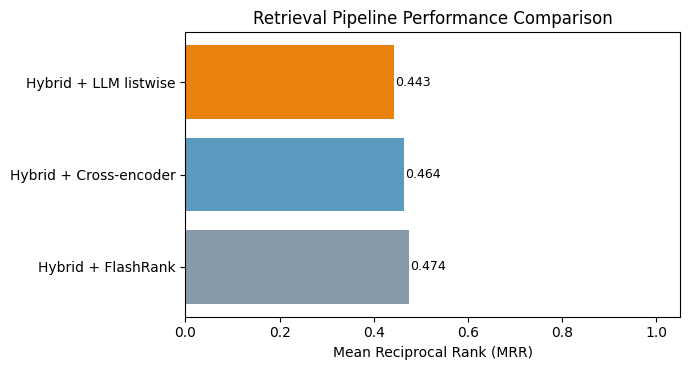

In [22]:
import matplotlib.pyplot as plt

# 1. Map 'rows' to the 'results' variable we generated earlier
rows = results

# 2. Execute your original plotting logic
fig, ax = plt.subplots(figsize=(7, 3.8))
names = [r["name"] for r in rows]
mrrs = [r["MRR"] for r in rows]

# Clean color coordination matching your setup
palette = ["#8899aa", "#5a9abf", "#e8820c", "#3dba6c", "#b05ac0"]
ax.barh(names, mrrs, color=palette[:len(rows)])

# Add value tags to the ends of the bars
for i, v in enumerate(mrrs):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=9)

# Clean up visual layout bounds
ax.set_xlim(0, 1.05)
ax.set_xlabel("Mean Reciprocal Rank (MRR)")
ax.set_title("Retrieval Pipeline Performance Comparison")
plt.tight_layout()
plt.show()

**Reading the numbers honestly.** The cross-encoder, FlashRank, and LLM rerankers each lift the
fused baseline to a perfect MRR here; **Cohere Rerank matched the baseline** on this run (it didn't
fix the single query the others did). With only **16 queries**, a one-query difference is *within
noise* — this is not a ranking of rerankers. The real takeaways: (1) reranking integrates cleanly,
including a managed API; (2) all of these are production-strong; **benchmark them on *your own*
labeled set** before choosing. (Cohere calls are throttled above to respect the Trial key's
10-calls/min limit.)

## 9. Pointwise vs. pairwise vs. listwise

- **Pointwise** — score each `(query, doc)` independently, then sort. Cross-encoders, FlashRank,
  Cohere. Simple, fast, parallelizable. *(most production rerankers)*
- **Pairwise** — compare two docs at a time ("is A more relevant than B?"). Higher quality signal,
  more comparisons.
- **Listwise** — order the whole candidate list at once (LLM/RankGPT). Best use of global context,
  slowest and priciest.

## 10. When to rerank, and which reranker

**Rerank when:** first-stage recall is good but the *ordering* is noisy (gold in top-k, not #1);
precision@k matters (few chunks reach the LLM); your latency budget allows ~50–500 ms.
**Skip when:** first stage is already precise, or latency is razor-thin and quality is adequate.

| Reranker | Quality | Latency | Cost / infra | Use when |
|----------|---------|---------|--------------|----------|
| **FlashRank** | good | very low (CPU) | free, tiny | edge / serverless / cost-sensitive |
| **Cross-encoder** (BGE-reranker-v2-m3) | high | medium (GPU helps) | self-host | default self-hosted choice |
| **Cohere / Jina Rerank** | high | low–med (API) | per-call, vendor | zero-ops, no model to run |
| **LLM listwise** | highest | high | per-call LLM | small candidate sets, nuanced intent |
| **ColBERT / late-interaction** | high | med | multi-vector index | token-sensitive corpora at scale |

**Candidate-set size:** retrieve **top 20–100**, rerank down to **top 3–10**. Bigger `k` = better
recall into the reranker but more latency; tune on your eval set.

## 11. Summary — the full retrieval pipeline

```
query ─▶ [ BM25  ┐
          [ Dense ┘─▶ RRF/weighted fusion ]  ─▶  rerank (top-k → top-5)  ─▶  grounded answer
```

- **Reranking is a precision second stage** over the fused candidates: `retrieve@k → rerank → top-5`.
- **Cross-encoders** are the default; **FlashRank** for cheap/CPU; **LLM listwise** for the highest
  quality on small sets; **Cohere/Jina** for managed; **ColBERT** for token-level at scale.
- On our labeled corpus, the local/LLM rerankers lift the fused baseline to perfect and the managed Cohere reranker matches it — differences across rerankers on 16 queries are within noise; the compounding, robust gain is the pipeline itself (Notebooks 06 → 07 → 08: sparse+dense → fuse → rerank).

### Where this sits
This completes the **retrieval** half of RAG: ingest → chunk → embed → index → **retrieve → fuse →
rerank**. The reranked top-k is exactly the grounded, cited context you feed the generator
(Notebook 01's pattern), now with production-grade recall *and* precision.